# PTI-Clima Notebooks

> Este cuaderno o notebook ilustra el uso de los conjuntos de datos de la PTI-Clima que se incluyen en el [almacén de datos](https://pti.climate.ifca.es/data). Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).

## Guía para el uso del dataset: NEX-GDDP-CMIP6 (Iberia y Canarias)

**Ezequiel Cimadevilla** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

Elegimos un modelo y un dominio.

In [2]:
model = "HadGEM3-GC31-LL"
domain = "Iberia" # or "Canarias"

Cargamos el inventario de datos y filtramos el dataset *NEX-GDDP-CMIP6*. El dataset contiene datos de múltiples modelos, en este caso seleccionamos *HadGEM3-GC31-LL* para el dominio *Iberia*.

In [3]:
df = pd.read_csv("~/data_inventory.csv")
gddp = df[df["source"] == "NEX-GDDP-CMIP6"]
subset = gddp[((gddp["dataset"].str.contains(model)) & (gddp["dataset"].str.contains(domain)))]
subset

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
357,HadGEM3-GC31-LL_r1i1p1f3_historical_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,historical,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
358,HadGEM3-GC31-LL_r1i1p1f3_ssp126_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp126,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
359,HadGEM3-GC31-LL_r1i1p1f3_ssp245_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp245,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
360,HadGEM3-GC31-LL_r1i1p1f3_ssp585_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp585,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN


Este notebook puede ser ejectudado para cualquier modelo disponible en el dataset *NEX-GDDP-CMIP6*, utilizando tanto el dominio *Iberia* como *Canarias*. A continuación se muestran todos los modelos climáticos disponibles.

In [4]:
gddp["dataset"].str.split("_", expand=True)[0].unique()

array(['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CESM2-WACCM',
       'CESM2', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1',
       'CanESM5', 'EC-Earth3-Veg-LR', 'EC-Earth3', 'FGOALS-g3',
       'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'HadGEM3-GC31-LL',
       'HadGEM3-GC31-MM', 'IITM-ESM', 'INM-CM4-8', 'INM-CM5-0',
       'IPSL-CM6A-LR', 'KACE-1-0-G', 'KIOST-ESM', 'MIROC-ES2L', 'MIROC6',
       'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3',
       'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL'], dtype=object)

Creamos un [dataset de xarray]() con los tres escenarios futuros (*ssp126*, *ssp245* y *ssp585*) y las tres variables de interés (*tas*, *tasmin* y *tasmax*).

In [5]:
ds = xr.concat(
    [xr.open_dataset(endpoint)[["tas", "tasmax", "tasmin"]].chunk({"time": 3096}) for endpoint in subset["endpoint"].iloc[1:]],
    dim=xr.Variable("scenario", list(subset["experiment"].iloc[1:])),
    coords="minimal",
    compat="override")

Hacemos un plot del primer paso de tiempo *(2015-01-01)* de la variable *tas* para los tres escenarios futuros.

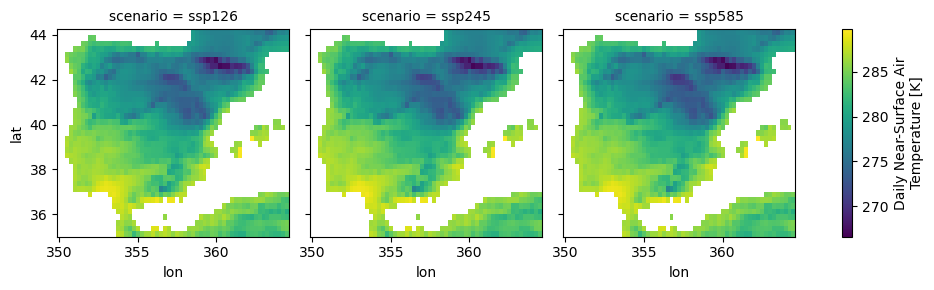

In [6]:
ds["tas"].isel(time=0).plot(col="scenario")

Calculamos la serie temporal para los tres escenarios, utilizando la media espacial de las tres variables.

In [7]:
%%time

ts = ds.mean(["lat", "lon"]).resample({"time": "YE"}).mean().compute(num_workers=4, scheduler="processes").convert_calendar("standard", use_cftime=False, align_on="date").to_array(dim="variable")

CPU times: user 1.71 s, sys: 71 ms, total: 1.78 s
Wall time: 49.6 s


Mostramos en un gráfico la evolución de las temperaturas para cada escenario futuro.

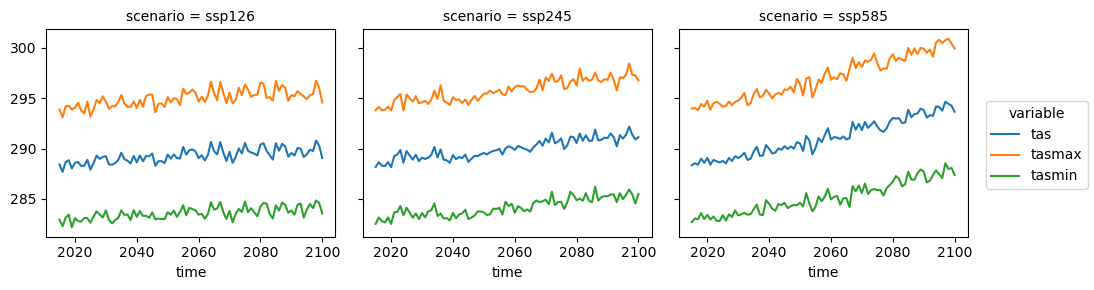

In [8]:
plot = ts.plot.line(x="time", col="scenario", xticks=ts.coords["time"][5::20])